# Lab 2 — Automatización: jobs, MTTR y outliers de duración

**Modalidad:** guiado · **Duración:** ~12 min
**Dataset:** `automation_runs.csv`

## Objetivo general
Medir la **confiabilidad de la automatización**: tasa de éxito, MTTR de jobs, distribución de retries y costo operativo por job.

## Entregable
Tabla por `job_name` con: runs, success_rate, retries promedio, MTTR (mediana y p95 de `duration_sec` agrupado por `status`).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

DATA = Path('..') / 'data'
runs = pd.read_csv(DATA / 'automation_runs.csv', parse_dates=['started_at'])
runs.head()

,run_id,job_name,started_at,duration_sec,status,retries,triggered_by,service
0,R-00001,failover_drill,2026-08-01 00:18:58.653520640,26.0,timeout,1,schedule,notifications
1,R-00002,purge_cache,2026-08-10 23:02:28.854685440,161.0,success,0,pipeline,notifications
2,R-00003,purge_cache,2026-08-07 14:23:14.583755520,17.0,success,2,alert,notifications
3,R-00004,purge_cache,2026-08-08 17:15:23.548491008,126.0,success,3,schedule,billing-worker
4,R-00005,db_vacuum,2026-08-14 20:10:45.527402240,113.0,failed,2,pipeline,auth-service


## 1. Diagnóstico de faltantes y errores técnicos

**Qué buscamos:** tres tipos de datos problemáticos — NaN en `duration_sec`, NaN en `job_name`, y duraciones físicamente imposibles.

**Por qué:** la imputación por grupo (mediana del job) preserva la forma del boxplot. Imputar con la global mezclaría escalas entre jobs.

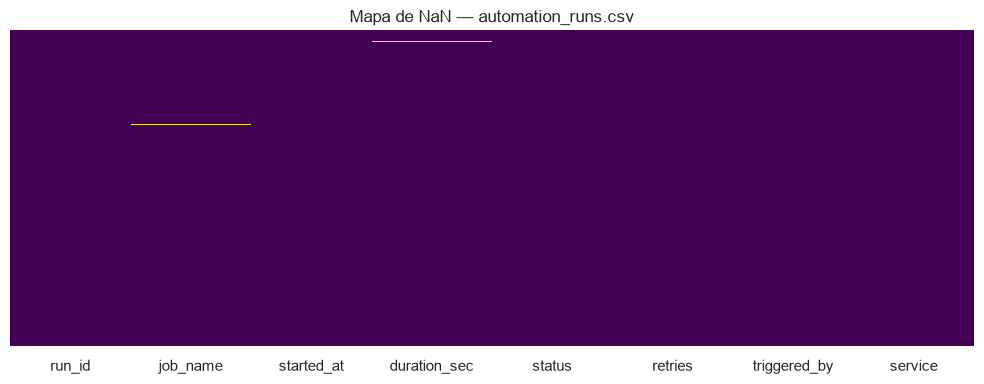

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(runs.isnull(), cbar=False, yticklabels=False, cmap='viridis')
ax.set_title('Mapa de NaN — automation_runs.csv')
plt.tight_layout()
plt.savefig('../html/lab2_fig1_nan.png', dpi=110, bbox_inches='tight')
plt.show()

In [3]:
bad = (runs['duration_sec'] < 0) | (runs['duration_sec'] > 86400)
print(f'duraciones imposibles: {bad.sum()}')
runs = runs.loc[~bad].copy()
med_by_job = runs.groupby('job_name')['duration_sec'].transform('median')
runs['duration_sec'] = runs['duration_sec'].fillna(med_by_job)
jobs_mode = runs['job_name'].mode().iloc[0]
runs['job_name'] = runs['job_name'].fillna(jobs_mode)
print('shape limpio:', runs.shape)

duraciones imposibles: 28
shape limpio: (1472, 8)


## 2. Distribución — boxplot por job (escala log)

**Qué buscamos:** separar jobs lentos reales (outliers arriba) de jobs normales.

**Por qué la escala log:** la mediana de `purge_cache` puede ser 2 s y la de `db_vacuum` 200 s. Sin log, los pequeños desaparecen.


**Qué buscamos:** saber qué servicios están sufriendo incidentes reales.

**Por qué importa Tukey (IQR × 1.5):**
- Media y p50 esconden los picos.
- La mediana es robusta, pero necesitamos un criterio operativo para etiquetar
  un valor como "anómalo" y actuar.

**Lectura del boxplot:**
- Caja = percentiles 25–75 (IQR).
- Rayita dentro = mediana.
- Bigotes = `Q3 + 1.5·IQR` (arriba) y `Q1 - 1.5·IQR` (abajo).
- Puntos fuera del bigote = outliers. Solo arriba = incidente unilateral.


C:\Users\andrescorrea\AppData\Local\Temp\ipykernel_33544\596096331.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


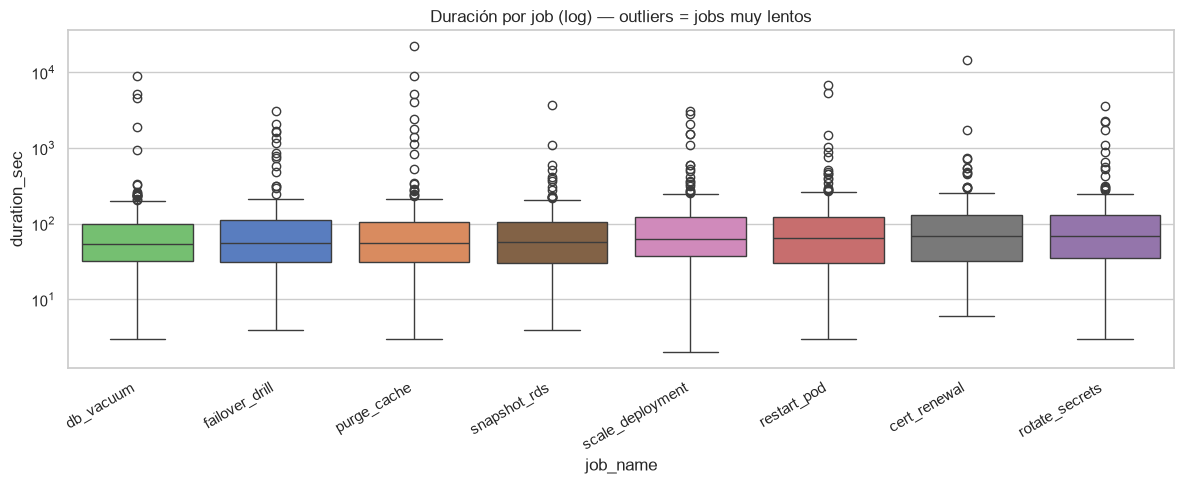

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
order = runs.groupby('job_name')['duration_sec'].median().sort_values().index
sns.boxplot(data=runs, x='job_name', y='duration_sec', order=order, hue='job_name', legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Duración por job (log) — outliers = jobs muy lentos')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../html/lab2_fig2_boxplot.png', dpi=110, bbox_inches='tight')
plt.show()

## 3. Métricas por job

**Qué buscamos:** ranking operativo de jobs por confiabilidad.

**Por qué importa:** con la success_rate y los retries vemos dónde la automatización está fallando más — candidato a ser reemplazada o tuneada.

In [5]:
by_job = runs.groupby('job_name').agg(
    runs=('run_id', 'count'),
    success_rate=('status', lambda s: (s == 'success').mean()),
    avg_retries=('retries', 'mean'),
    p50_dur=('duration_sec', lambda s: s.quantile(0.5)),
    p95_dur=('duration_sec', lambda s: s.quantile(0.95)),
)
by_job.sort_values('success_rate')

,runs,success_rate,avg_retries,p50_dur,p95_dur
job_name,,,,,
failover_drill,163,0.846626,0.773006,55.0,719.30
cert_renewal,176,0.863636,1.034091,69.0,340.25
scale_deployment,200,0.865000,0.845000,63.0,423.85
purge_cache,189,0.867725,0.962963,56.0,459.20
snapshot_rds,186,0.887097,0.876344,58.0,232.75
rotate_secrets,180,0.888889,0.966667,69.5,430.95
db_vacuum,187,0.898396,0.796791,54.0,245.60
restart_pod,191,0.900524,1.000000,64.5,428.00


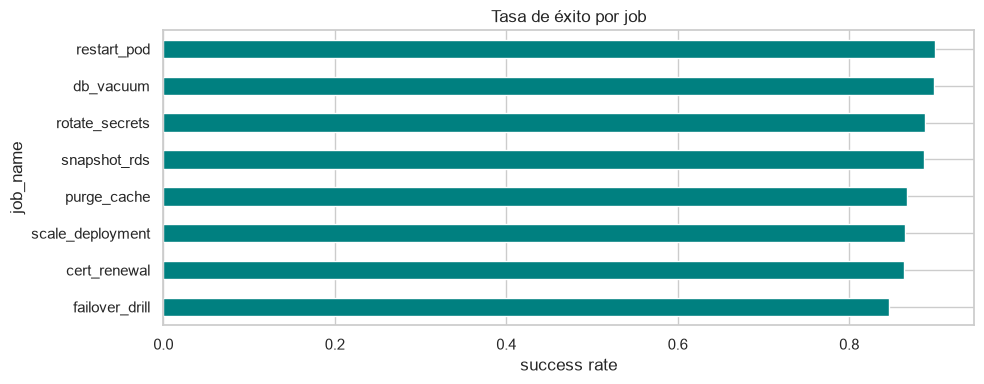

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
by_job['success_rate'].sort_values().plot(kind='barh', color='teal', ax=ax)
ax.set_title('Tasa de éxito por job')
ax.set_xlabel('success rate')
plt.tight_layout()
plt.savefig('../html/lab2_fig3_success.png', dpi=110, bbox_inches='tight')
plt.show()

## 4. MTTR — mediana de duración en fallos

**Qué entendemos por MTTR:** tiempo que tarda el job en *fallar* o hacer timeout. No la duración de runs exitosos.

**Por qué la mediana y no la media:** porque en fallos suele haber valores extremos.

In [7]:
failed = runs[runs['status'].isin(['failed', 'timeout'])]
mttr = failed.groupby('job_name')['duration_sec'].median().rename('mttr_sec')
by_job_full = by_job.join(mttr).fillna(0)
by_job_full.sort_values('mttr_sec', ascending=False)

,runs,success_rate,avg_retries,p50_dur,p95_dur,mttr_sec
job_name,,,,,,
failover_drill,163,0.846626,0.773006,55.0,719.30,73.0
scale_deployment,200,0.865000,0.845000,63.0,423.85,67.0
db_vacuum,187,0.898396,0.796791,54.0,245.60,66.0
purge_cache,189,0.867725,0.962963,56.0,459.20,58.0
snapshot_rds,186,0.887097,0.876344,58.0,232.75,58.0
rotate_secrets,180,0.888889,0.966667,69.5,430.95,57.5
restart_pod,191,0.900524,1.000000,64.5,428.00,57.0
cert_renewal,176,0.863636,1.034091,69.0,340.25,53.0


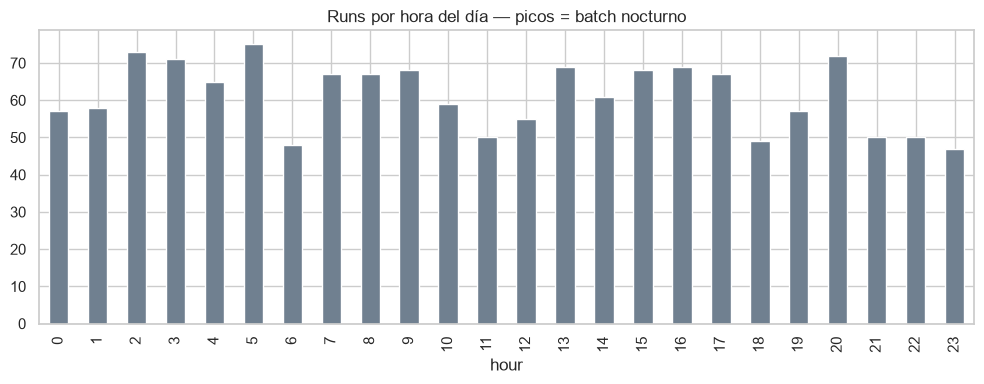

In [8]:
# Conteo de ejecuciones por hora del dia (ciclo)
runs['hour'] = runs['started_at'].dt.hour
fig, ax = plt.subplots(figsize=(10, 4))
runs.groupby('hour').size().plot(kind='bar', color='slategray', ax=ax)
ax.set_title('Runs por hora del día — picos = batch nocturno')
plt.tight_layout()
plt.savefig('../html/lab2_fig4_hourly.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Distribución por trigger

**Qué buscamos:** qué origen dispara más automatización y cuál falla más.

**Por qué importa:** un trigger ruidoso es candidato a mejor runbook o a alertas que no deberían terminar en un job automático.

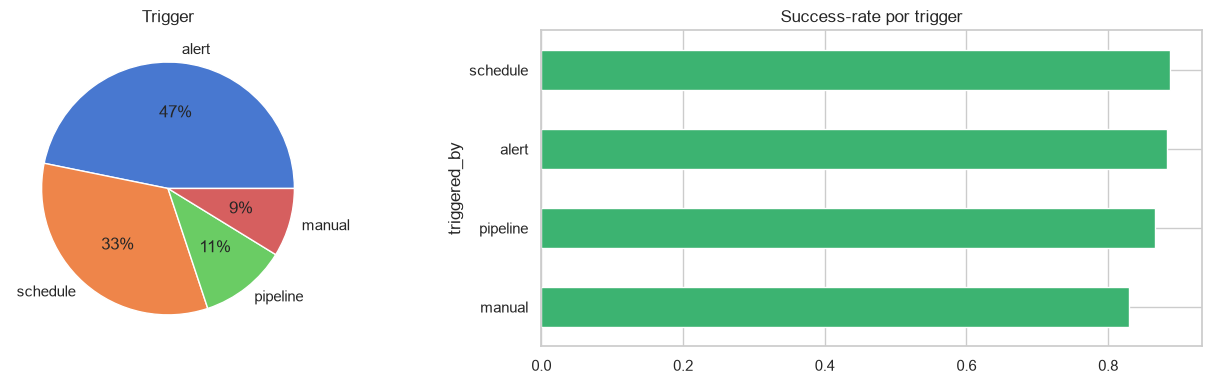

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
runs['triggered_by'].value_counts().plot(kind='pie', ax=ax[0], autopct='%1.0f%%')
ax[0].set_ylabel('')
ax[0].set_title('Trigger')
success_by_trigger = runs.groupby('triggered_by').apply(lambda g: (g['status']=='success').mean())
success_by_trigger.sort_values().plot(kind='barh', color='mediumseagreen', ax=ax[1])
ax[1].set_title('Success-rate por trigger')
plt.tight_layout()
plt.savefig('../html/lab2_fig5_trigger.png', dpi=110, bbox_inches='tight')
plt.show()

## Para discutir
- ¿Qué job explica más del 50 % del `mttr` total?
- ¿Cuál trigger es el más ruidoso (más fallos)?
- Cómo decidir si un outlier es **saturación** o **bug**.